# DQN Taxi 10×8 - Workflow Complet

Entraînement, évaluation et visualisation dans un seul notebook simple.

In [26]:
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

# Rechargement forcé du module env pour appliquer les dernières modifications
if 'env' in sys.modules:
    del sys.modules['env']
from env import SimpleTaxiEnv

print("✓ Imports réussis (module env rechargé)")

✓ Imports réussis (module env rechargé)


import os

env = SimpleTaxiEnv()

print("✓ ENVIRONNEMENT CRÉÉ")
print(f"  Grille : {env.grid_width}×{env.grid_height}")
print(f"  Observation space : {env.observation_space}")
print(f"  Action space : {env.action_space}")
print(f"  Max steps : {env.max_steps}")

# Afficher les zones générées
obs, _ = env.reset()
print(f"\n✓ REMPARTS FIXES")
print(f"  Nombre de remparts : {len(env.walls)}")
print(f"  Positions des remparts : {sorted(env.walls)}")
print(f"\n  Passagers :")
for i, p in enumerate(env.passengers):
    if p.get("active"):
        print(f"    Passager {i+1}: Pickup({p['x']}, {p['y']}) → Dropoff({p['dest_x']}, {p['dest_y']})")
print(f"\n  Observation shape : {obs.shape}")

env.close()

In [27]:
## 2. Entraînement DQN

## 2. Entraînement DQN

In [ ]:
import os
from stable_baselines3.common.monitor import Monitor

log_dir = "logs"
os.makedirs(log_dir, exist_ok=True)

# Environnement monitoré pour enregistrer les récompenses
env = Monitor(SimpleTaxiEnv(), filename=os.path.join(log_dir, "monitor.csv"))

agent = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=1e-4,
    buffer_size=100_000,
    batch_size=64,
    gamma=0.99,
    target_update_interval=1000,
    exploration_fraction=0.5,  # Augmenté pour une exploration plus longue
    exploration_final_eps=0.05,
    verbose=1,
)

print("\n" + "="*60)
print("ENTRAÎNEMENT DQN - REMPARTS FIXES + POSITIONS ALÉATOIRES")
print("="*60)
print("Timesteps : 1,000,000")  # Augmenté
print("Exploration fraction : 0.5") # Augmenté
print("Learning rate : 1e-4")
print("Buffer size : 100,000")
print("Batch size : 64")
print("Remparts : 4 (fixes)")
print("Max steps : 200")
print("Récompense step : -0.01")
print("Pénalité collision : -2.0")
print("Shaping dist : +1 (rapprochement), -2 (éloignement)")
print("Récompense pickup : 10.0")
print("Récompense dropoff : 50.0")
print("Passagers : 1 ou 2 aléatoirement")
print("="*60 + "\n")

agent.learn(total_timesteps=1_000_000) # Augmenté

os.makedirs("models", exist_ok=True)
agent.save("models/dqn_taxi")
print("\n✓ Modèle sauvegardé → models/dqn_taxi.zip")

env.close()

Using cpu device
Wrapping the env in a DummyVecEnv.

ENTRAÎNEMENT DQN - REMPARTS FIXES + POSITIONS ALÉATOIRES
Timesteps : 300,000
Learning rate : 1e-4 (corrigé)
Buffer size : 100,000
Batch size : 64
Remparts : 4 (fixes)
Max steps : 200
Récompense step : -0.01
Pénalité collision : -2.0
Shaping dist : +1 (rapprochement), -2 (éloignement), -1 (égalité)
Récompense pickup : 10.0
Récompense dropoff : 50.0
Passagers : 1 ou 2 aléatoirement

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 200      |
|    ep_rew_mean      | -112     |
|    exploration_rate | 0.983    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2086     |
|    time_elapsed     | 0        |
|    total_timesteps  | 800      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.726    |
|    n_updates        | 174      |
----------------------------------
----------------------------------
| r

In [29]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from stable_baselines3.common.results_plotter import load_results, ts2xy

# # Courbe d'apprentissage (récompense par épisode) depuis logs/monitor.csv
# log_dir = "logs"

# if os.path.exists(os.path.join(log_dir, "monitor.csv")):
#     results = load_results(log_dir)
#     x, y = ts2xy(results, "r")  # r = rewards par épisode

#     plt.figure(figsize=(10, 5))
    
#     # Courbe brute (transparente)
#     plt.plot(x, y, alpha=0.3, color="gray", label="Reward brute")
    
#     # Courbe lissée (moyenne mobile)
#     window = max(1, len(y) // 10)  # Fenêtre adaptative
#     if len(y) > window:
#         y_smooth = np.convolve(y, np.ones(window)/window, mode="valid")
#         x_smooth = x[len(x) - len(y_smooth):]
#         plt.plot(x_smooth, y_smooth, label=f"Moyenne mobile (fenêtre={window})", color="blue", linewidth=2)
    
#     plt.xlabel("Timesteps")
#     plt.ylabel("Récompense par épisode")
#     plt.title("Courbe d'apprentissage")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()
    
#     print(f"Meilleure moyenne (lissée) : {np.max(y_smooth) if len(y) > window else np.max(y):.2f}")
# else:
#     print("⚠ Aucun log trouvé. Veuillez lancer l'entraînement (cellule précédente) d'abord.")

In [30]:
import importlib
import env
importlib.reload(env)  # Force le rechargement de la dernière version de env.py
from env import SimpleTaxiEnv
from stable_baselines3 import DQN

# Charger l'environnement à jour
eval_env = SimpleTaxiEnv()
print(f"✓ Environnement rechargé | Max steps: {eval_env.max_steps} (Doit être 200)")

# Charger le modèle
try:
    model = DQN.load("models/dqn_taxi", env=eval_env)
    print("✓ Modèle chargé")
except:
    print("⚠ Modèle non trouvé")
    model = None

if model:
    print("\n" + "="*60)
    print("ÉVALUATION APRÈS RELOAD")
    print("="*60)

    n_eval_episodes = 10
    total_rewards = []
    successes = 0

    for ep in range(n_eval_episodes):
        obs, _ = eval_env.reset()
        done = False
        truncated = False
        ep_reward = 0
        steps = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, _ = eval_env.step(action)
            ep_reward += reward
            steps += 1
        
        total_rewards.append(ep_reward)
        # Succès si tous les passagers prévus ont été livrés
        if eval_env.delivered == eval_env.num_passengers:
            successes += 1
            
        print(f"Episode {ep+1}: Reward={ep_reward:.1f}, Steps={steps}, Livrés={eval_env.delivered}/{eval_env.num_passengers}")

    print("="*60)
    print(f"Taux de succès moyen : {successes/n_eval_episodes*100:.1f}%")
    print(f"Récompense moyenne   : {np.mean(total_rewards):.1f}")
    print("="*60)

eval_env.close()

✓ Environnement rechargé | Max steps: 200 (Doit être 200)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


✓ Modèle chargé

ÉVALUATION APRÈS RELOAD
Episode 1: Reward=-2.0, Steps=200, Livrés=0/2
Episode 2: Reward=-2.0, Steps=200, Livrés=0/1
Episode 3: Reward=-2.0, Steps=200, Livrés=0/1
Episode 4: Reward=-2.0, Steps=200, Livrés=0/2
Episode 5: Reward=-2.0, Steps=200, Livrés=0/2
Episode 6: Reward=-2.0, Steps=200, Livrés=0/2
Episode 7: Reward=-2.0, Steps=200, Livrés=0/1
Episode 8: Reward=-2.0, Steps=200, Livrés=0/1
Episode 9: Reward=-0.0, Steps=200, Livrés=0/1
Episode 10: Reward=-2.0, Steps=200, Livrés=0/1
Taux de succès moyen : 0.0%
Récompense moyenne   : -1.8


In [31]:
env = SimpleTaxiEnv()
agent = DQN.load("models/dqn_taxi", env=env)

print("="*60)
print("ÉVALUATION")
print("="*60)

total_reward = 0
success_count = 0

for episode in range(10):
    obs, _ = env.reset()
    episode_reward = 0
    done = False
    
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        done = terminated or truncated
    
    total_reward += episode_reward
    if env.delivered == 2:
        success_count += 1
    
    print(f"Episode {episode+1}: Reward={episode_reward:.1f}, Delivered={env.delivered}/2")

print(f"\nMoyenne: {total_reward/10:.1f}")
print(f"Taux de succès: {success_count}/10 ({success_count*10}%)")

env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
ÉVALUATION
Episode 1: Reward=-2.0, Delivered=0/2
Episode 2: Reward=-2.0, Delivered=0/2
Episode 3: Reward=-2.0, Delivered=0/2
Episode 4: Reward=-1.0, Delivered=0/2
Episode 5: Reward=-2.0, Delivered=0/2
Episode 6: Reward=-2.0, Delivered=0/2
Episode 7: Reward=-2.0, Delivered=0/2
Episode 8: Reward=-2.0, Delivered=0/2
Episode 9: Reward=-2.0, Delivered=0/2
Episode 10: Reward=-2.0, Delivered=0/2

Moyenne: -1.9
Taux de succès: 0/10 (0%)


## 3. Évaluation

In [32]:
env = SimpleTaxiEnv()
agent = DQN.load("models/dqn_taxi", env=env)

rewards = []
steps = []
successes = 0

print("\nÉvaluation en cours (200 épisodes)...\n")

for ep in range(200):
    obs, _ = env.reset()
    total_reward = 0
    step_count = 0
    done = False
    
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        step_count += 1
        done = terminated or truncated
    
    rewards.append(total_reward)
    steps.append(step_count)
    if terminated:
        successes += 1
    
    if (ep + 1) % 50 == 0:
        print(f"Episode {ep + 1}/200 - Succès: {successes}/{ep + 1}")

success_rate = successes / 200 * 100

print("\n" + "="*60)
print("RÉSULTATS FINAUX")
print("="*60)
print(f"Taux de succès        : {success_rate:.1f}%")
print(f"Récompense moyenne    : {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
print(f"Pas moyens            : {np.mean(steps):.1f} ± {np.std(steps):.1f}")
print(f"Min/Max récompense    : {np.min(rewards):.0f} / {np.max(rewards):.0f}")
print(f"Min/Max pas           : {np.min(steps)} / {np.max(steps)}")
print("="*60)

env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

Évaluation en cours (200 épisodes)...

Episode 50/200 - Succès: 0/50
Episode 100/200 - Succès: 0/100
Episode 150/200 - Succès: 0/150
Episode 200/200 - Succès: 0/200

RÉSULTATS FINAUX
Taux de succès        : 0.0%
Récompense moyenne    : -1.71 ± 1.06
Pas moyens            : 200.0 ± 0.0
Min/Max récompense    : -2 / 6
Min/Max pas           : 200 / 200


## 4. Visualisations

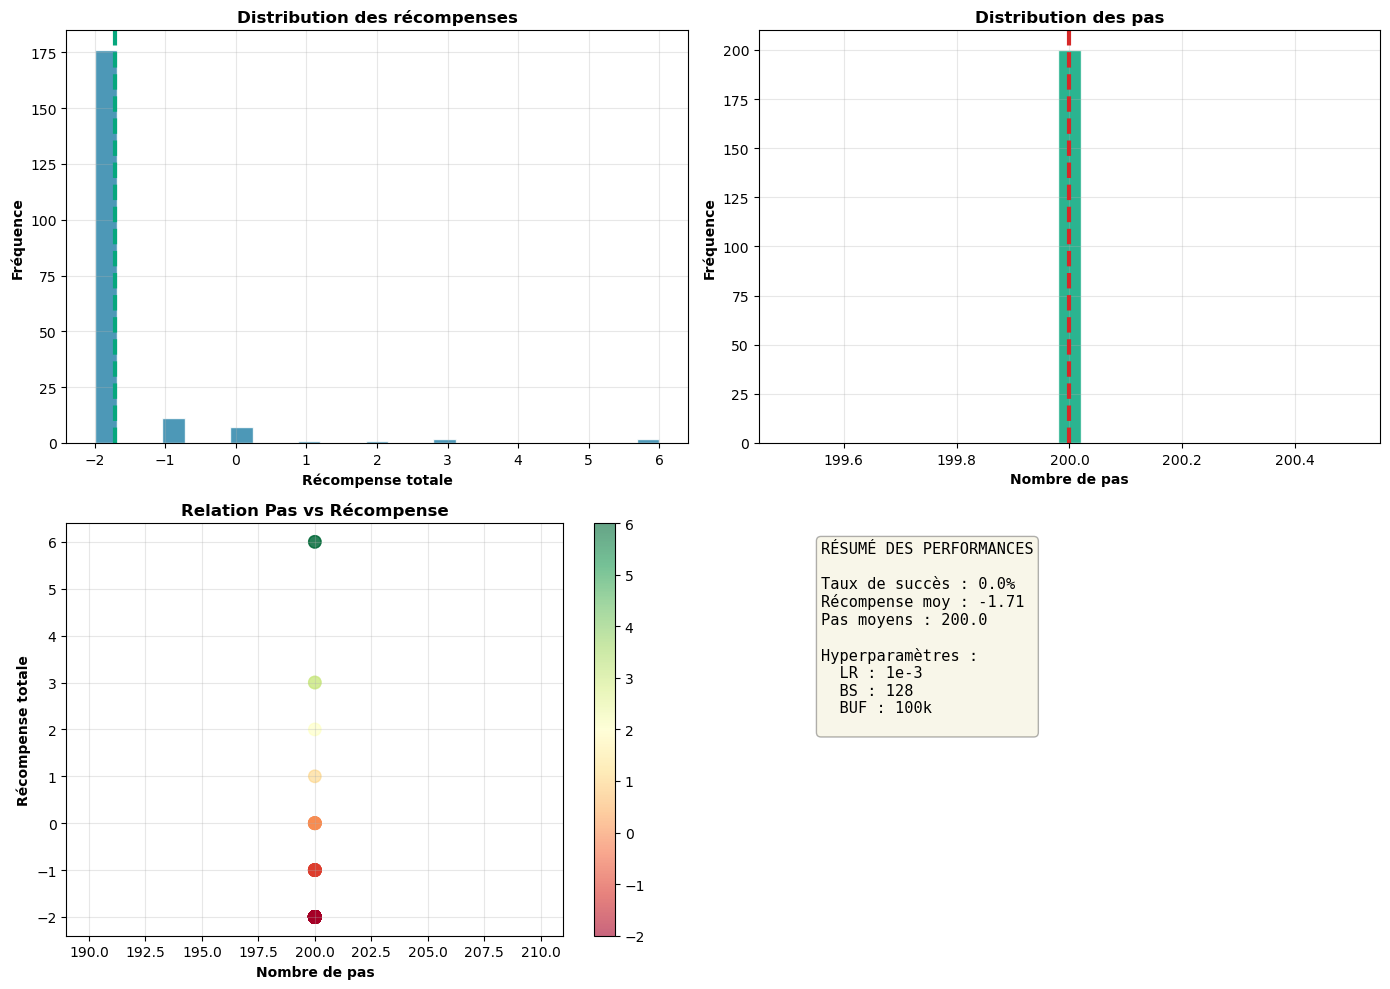

✓ Graphe sauvegardé → results.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution récompenses
axes[0, 0].hist(rewards, bins=25, color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(np.mean(rewards), color='#06A77D', linewidth=3, linestyle='--')
axes[0, 0].set_xlabel('Récompense totale', fontweight='bold')
axes[0, 0].set_ylabel('Fréquence', fontweight='bold')
axes[0, 0].set_title('Distribution des récompenses', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Distribution pas
axes[0, 1].hist(steps, bins=25, color='#06A77D', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(np.mean(steps), color='#D62828', linewidth=3, linestyle='--')
axes[0, 1].set_xlabel('Nombre de pas', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title('Distribution des pas', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Scatter reward vs steps
scatter = axes[1, 0].scatter(steps, rewards, alpha=0.6, s=80, c=rewards, cmap='RdYlGn')
axes[1, 0].set_xlabel('Nombre de pas', fontweight='bold')
axes[1, 0].set_ylabel('Récompense totale', fontweight='bold')
axes[1, 0].set_title('Relation Pas vs Récompense', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0])

# KPI
axes[1, 1].axis('off')
kpi_text = f"""RÉSUMÉ DES PERFORMANCES

Taux de succès : {success_rate:.1f}%
Récompense moy : {np.mean(rewards):.2f}
Pas moyens : {np.mean(steps):.1f}

Hyperparamètres :
  LR : 1e-3
  BS : 128
  BUF : 100k
"""
axes[1, 1].text(0.1, 0.5, kpi_text, fontsize=11, family='monospace',
               bbox=dict(boxstyle='round', facecolor='#EAE2B7', alpha=0.3))

plt.tight_layout()
plt.savefig('results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graphe sauvegardé → results.png")